In [1]:
from keras.datasets import mnist
from matplotlib import pyplot as plt
import sklearn.datasets
from sklearn import datasets
import numpy as np
import seaborn
from mpl_toolkits.mplot3d import Axes3D

Using TensorFlow backend.


In [2]:
# dataset
(_, _), (x_train, y_train) = mnist.load_data() 
n_rows = 10000
x_train = x_train[:n_rows]
y_train = y_train[:n_rows]

print('x train shape :', x_train.shape, '    y train shape:', y_train.shape)
x_train = x_train.reshape(x_train.shape[0], 28*28).astype('float32') # (1,28*28)
print('x train shape ', x_train.shape)

x train shape : (10000, 28, 28)     y train shape: (10000,)
x train shape  (10000, 784)


vals shape (784,)
vects shape (784, 784)


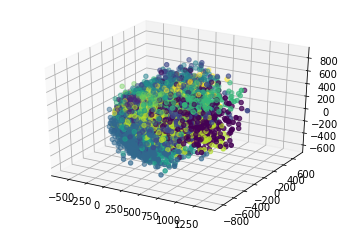

In [4]:
# numpy PCA 
def pca_for_mnist(data):
    mean_cols = np.mean(data.T, axis=1) # 转为(784,10000), 计算每一个维度(共784个维度)
    center = data - mean_cols # 去中心化
    covariance = np.cov(center.T) # 计算协方差矩阵
    vals, vects = np.linalg.eig(covariance) # 得到特征值，特征向量
    print('vals shape', vals.shape) # (784)
    print('vects shape', vects.shape) # (784, 784)
    idx = np.argsort(vals)[::-1] # 由大到小获得下标
    vects = np.real(vects[idx])
    vals = np.real(vals[idx])
    project = vects.T.dot(center.T) # 使用特征向量 对 中心化数据进行点乘
    #         (784, 784)  *  (784, 10000)
    return project

new_X = pca_for_mnist(x_train).T

fig = plt.figure()
ax = fig.gca(projection='3d') # get current axes 
ax.scatter(new_X[:,0], new_X[:,1], new_X[:,2], c=y_train) # 找到前三维主要特征
plt.show()


In [3]:
# 重构后效果
# pass

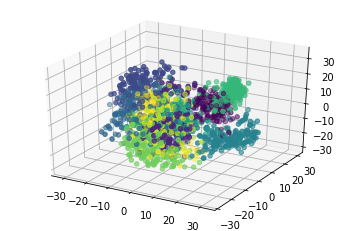

In [5]:
# PCA sklearn
from sklearn import datasets
from sklearn import decomposition
import matplotlib.pyplot as plt
import numpy as np
import seaborn
from mpl_toolkits.mplot3d import Axes3D

mnist = datasets.load_digits()
X = mnist.data
y = mnist.target
pca = decomposition.PCA(n_components=3)
new_X = pca.fit_transform(X)
fig = plt.figure()
ax = fig.gca(projection='3d')
ax.scatter(new_X[:, 0], new_X[:, 1], new_X[:, 2], c=y)
plt.show()

In [5]:
# LDA sklearn

import numpy as np

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
x = np.asarray([[-1, -1], [-2, -1], [-3, -2], [1,1], [2, 1], [3,2]])
y = [1,1,1,2,2,2]
clf = LinearDiscriminantAnalysis()
clf.fit(x,y)
print(clf)
print(clf.predict([[-0.8, -1]]))


LinearDiscriminantAnalysis(n_components=None, priors=None, shrinkage=None,
                           solver='svd', store_covariance=False, tol=0.0001)
[1]


In [ ]:
# numpy LDA 